# S02-B01-Bank_Transactions

## Importation & Exploration

In [545]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("bank_transactions.csv")

In [546]:
df.head()

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,NaN,Premium,16415.1,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,NaN,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.2,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN


In [547]:
df.shape

(2060, 16)

In [548]:
df.dtypes

transaction_id             str
client_id                  str
date_transaction           str
montant                    str
devise                     str
taux_change_eur        float64
montant_eur            float64
categorie                  str
produit                    str
agence                     str
type_operation             str
statut                     str
score_credit_client    float64
segment_client             str
solde_avant                str
taux_interet           float64
dtype: object

In [549]:
df.describe()

,taux_change_eur,montant_eur,score_credit_client,taux_interet
count,2060.000000,2060.000000,1893.000000,0.0
mean,1.534782,-116.223170,627.866350,NaN
std,2.234708,2083.777234,132.193879,NaN
min,0.860000,-8705.810000,-100.000000,NaN
25%,1.000000,-1218.870000,586.000000,NaN
50%,1.000000,-60.405000,643.000000,NaN
75%,1.000000,957.805000,701.000000,NaN
max,10.850000,9026.940000,1500.000000,NaN


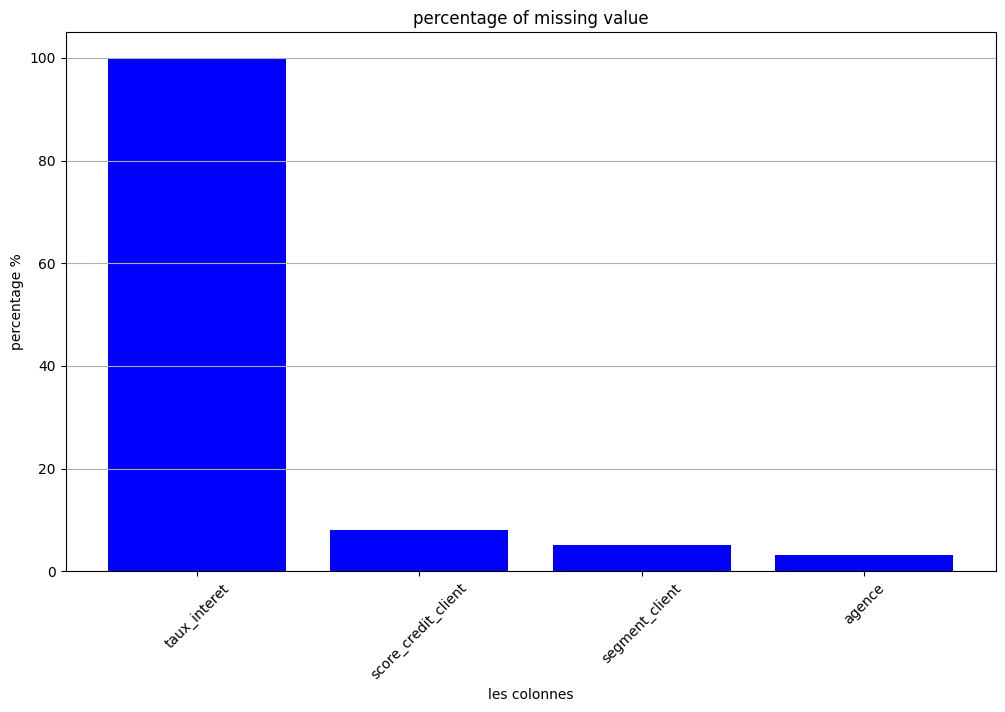

In [550]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12,7))
plt.bar(missing_percent.index, missing_percent.values, color="blue")
plt.title("percentage of missing value")
plt.xlabel("les colonnes")
plt.ylabel("percentage %")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [551]:
duplicates = df[df.duplicated(subset=["transaction_id"], keep=False)]
duplicates.shape

(120, 16)

## Nettoyage des données

In [552]:
df = df.drop(columns=["taux_interet"])

In [553]:
df = df.drop_duplicates(subset=["transaction_id"], keep="first")

In [554]:
df["date_transaction"] = pd.to_datetime(df["date_transaction"],errors="coerce" , format="%Y-%m-%d %H:%M:%S")
df = df.dropna(subset=["date_transaction"])

In [555]:
df["montant"] = df["montant"].str.replace(",", ".").astype(float)

In [556]:
df["solde_avant"] = df["solde_avant"].str.replace("EUR", "").str.strip().astype(float)

In [557]:
df["devise"] = df["devise"].str.upper()

In [558]:
df["segment_client"] = df["segment_client"].str.lower().str.capitalize()

In [559]:
mode_value_1 = df["segment_client"].mode()[0]
df["segment_client"] = df["segment_client"].fillna(mode_value_1)

In [560]:
df["agence"] = df["agence"].str.strip()

In [561]:
mode_value_2 = df["agence"].mode()[0]
df["agence"] = df["agence"].fillna(mode_value_2)

## Valeurs Aberrantes

In [562]:
# Remove anomalies
df.loc[(df["score_credit_client"] < 300) | (df["score_credit_client"] > 850), "score_credit_client"] = None

# Median imputation
median_score = df["score_credit_client"].median()
df["score_credit_client"] = df["score_credit_client"].fillna(median_score)

In [563]:
Q1 = df["montant"].quantile(0.25)
Q3 = df["montant"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["is_anomaly_montant"] = (df["montant"] < lower) | (df["montant"] > upper)
df["is_anomaly_montant"].value_counts()

is_anomaly_montant
False    1820
True      105
Name: count, dtype: int64

## Feature Engineering

In [564]:
df["anne"] = df["date_transaction"].dt.year
df["trimestre"] = df["date_transaction"].dt.quarter
df["mois"] = df["date_transaction"].dt.month
df["jour_semaine"] = df["date_transaction"].dt.day_name()
df[["date_transaction", "anne", "trimestre", "mois", "jour_semaine"]].head()

,date_transaction,anne,trimestre,mois,jour_semaine
0,2022-04-19 02:31:00,2022,2,4,Tuesday
1,2024-06-20 20:51:00,2024,2,6,Thursday
2,2024-08-28 05:03:00,2024,3,8,Wednesday
3,2024-01-07 08:16:00,2024,1,1,Sunday
4,2024-08-11 19:52:00,2024,3,8,Sunday


In [565]:
df["montant_eur_verifie"] = df["montant"] / df["taux_change_eur"]
df["ecart_eur"] = df["montant_eur"] - df["montant_eur_verifie"]
df["is_conversion_error"] = (df["ecart_eur"] > 1) | (df["ecart_eur"] < -1)
df["is_conversion_error"].value_counts()

is_conversion_error
False    1895
True       30
Name: count, dtype: int64

In [566]:
def categorize(score):
    if score >= 700:
        return "Low"

    elif score < 580:
        return "High"
    
    else:
        return "Medium"

df["categorie_risque"] = df["score_credit_client"].apply(categorize)

In [567]:
df["crédits"] = df["montant"].apply(
    lambda x: x if x > 0 else 0
)
df["débits"] = df["montant"].apply(
    lambda x: x if x < 0 else 0
)

solde_client = df.groupby("client_id")[["crédits", "débits"]].sum()

solde_client["solde_net"] = solde_client["crédits"] - solde_client["débits"]

df = df.merge(solde_client[["solde_net"]], on="client_id", how="left")

solde_client.head()

,crédits,débits,solde_net
client_id,,,
CLI0001,12701.54,-11185.00,23886.54
CLI0002,3111.29,-7915.60,11026.89
CLI0003,5172.85,-15284.60,20457.45
CLI0004,7057.71,-8487.02,15544.73
CLI0005,1479.92,-9816.90,11296.82


In [568]:
agg_client = df.groupby("client_id").agg({
    "transaction_id" : "count",
    "montant" : "mean",
    "produit" : "nunique"
}).rename(columns={
    "transaction_id" : "nb_transactions",
    "montant" : "montant_moyen",
    "produit" : "nb_produits_distincts"
})
agg_client.head()

,nb_transactions,montant_moyen,nb_produits_distincts
client_id,,,
CLI0001,14,108.324286,6
CLI0002,10,-480.431000,6
CLI0003,13,-777.826923,7
CLI0004,15,-95.287333,7
CLI0005,8,-1042.122500,6


In [569]:
taux_rejet = df.groupby("agence")["statut"].apply(
    lambda x: (x == "Rejete").mean() * 100
).reset_index(name="taux_rejet")
round(taux_rejet, 2)

,agence,taux_rejet
0,Bordeaux-Meriadeck,4.71
1,Lille-Grand-Place,4.37
2,Lyon-Part-Dieu,4.15
3,Marseille-Vieux-Port,5.61
4,Nantes-Commerce,8.85
5,Nice-Massena,8.00
6,Paris-Centre,6.73
7,Toulouse-Capitole,6.52


## Export

In [570]:
df.to_csv("financecore_clean.csv", index=False)

In [571]:
df.shape

(1925, 27)